<a href="https://colab.research.google.com/github/Optimus0205/Sales-Forecasting/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Forcasting


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

##Task 1 — Data Loading, Merging & Deep Exploration


- Load the Superstore Sales CSV using Pandas

In [ ]:
df=pd.read_csv('/content/train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.shape

(4824, 18)

- Parse the Order Date and Ship Date columns as proper datetime objects

In [ ]:
df['Order Date']=pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']=pd.to_datetime(df['Ship Date'], dayfirst=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


- Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season

In [ ]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Week Number'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['Order Day of Week'] = df['Order Date'].dt.dayofweek
df['Order Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Order Season'] = df['Order Month'].apply(get_season)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Order Week Number,Order Day of Week,Order Quarter,Order Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,2,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,2,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,0,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,1,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,1,4,Autumn


- Check for missing values, duplicates, and data type issues


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4824 entries, 0 to 4823
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             4824 non-null   int64         
 1   Order ID           4824 non-null   object        
 2   Order Date         4824 non-null   datetime64[ns]
 3   Ship Date          4824 non-null   datetime64[ns]
 4   Ship Mode          4824 non-null   object        
 5   Customer ID        4824 non-null   object        
 6   Customer Name      4824 non-null   object        
 7   Segment            4824 non-null   object        
 8   Country            4824 non-null   object        
 9   City               4824 non-null   object        
 10  State              4824 non-null   object        
 11  Postal Code        4823 non-null   float64       
 12  Region             4824 non-null   object        
 13  Product ID         4824 non-null   object        
 14  Category

In [ ]:
df['Postal Code'].isna().sum()

np.int64(1)

In [ ]:
df[df['Postal Code'].isna()]
# Empty value of postal code for Burlington City, Vermont State, US  -> postal code value '05401'

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Order Week Number,Order Day of Week,Order Quarter,Order Season
2234,2235,CA-2018-104066,2018-12-05,2018-12-10,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03,2018,12,49,2,4,Winter


Empty value of postal code for Burlington City, Vermont State, US  -> postal code value '05401'

In [ ]:
df['Postal Code'].fillna('05401', inplace=True)

/tmp/ipykernel_1712/1714574116.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Postal Code'].fillna('05401', inplace=True)
/tmp/ipykernel_1712/1714574116.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '05401' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['Postal Code'].fillna('05401', inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4824 entries, 0 to 4823
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             4824 non-null   int64         
 1   Order ID           4824 non-null   object        
 2   Order Date         4824 non-null   datetime64[ns]
 3   Ship Date          4824 non-null   datetime64[ns]
 4   Ship Mode          4824 non-null   object        
 5   Customer ID        4824 non-null   object        
 6   Customer Name      4824 non-null   object        
 7   Segment            4824 non-null   object        
 8   Country            4824 non-null   object        
 9   City               4824 non-null   object        
 10  State              4824 non-null   object        
 11  Postal Code        4824 non-null   object        
 12  Region             4824 non-null   object        
 13  Product ID         4824 non-null   object        
 14  Category

In [ ]:
df.duplicated().sum()

np.int64(0)

- Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)

### Aggregate Daily Sales into Weekly and Monthly Totals

In [ ]:
df_sales = df[['Order Date', 'Sales']].copy()
df_sales.set_index('Order Date', inplace=True)

# Aggregate to weekly sales
df_weekly_sales = df_sales.resample('W')['Sales'].sum().reset_index()
df_weekly_sales.rename(columns={'Order Date': 'Week Start Date', 'Sales': 'Weekly Sales'}, inplace=True)

print('Weekly Sales (first 5 rows):')
df_weekly_sales.head()

Weekly Sales (first 5 rows):


,Week Start Date,Weekly Sales
0,2015-01-04,288.060
1,2015-01-11,124.850
2,2015-01-18,2283.114
3,2015-01-25,1859.400
4,2015-02-01,2134.774


In [ ]:
# Aggregate to monthly sales
df_monthly_sales = df_sales.resample('ME')['Sales'].sum().reset_index()
df_monthly_sales.rename(columns={'Order Date': 'Month End Date', 'Sales': 'Monthly Sales'}, inplace=True)

print('\nMonthly Sales (first 5 rows):')
df_monthly_sales.head()


Monthly Sales (first 5 rows):


,Month End Date,Monthly Sales
0,2015-01-31,6221.298
1,2015-02-28,1362.506
2,2015-03-31,34169.059
3,2015-04-30,13391.855
4,2015-05-31,11148.103


- Answer these questions in your notebook with data to back each one:
    - Which product category generates the highest total revenue?

In [ ]:
df['Sales'].groupby(df['Category']).sum().reset_index(name='Total Revenue').sort_values(by='Total Revenue', ascending=False)

,Category,Total Revenue
2,Technology,421603.3530
0,Furniture,342208.3097
1,Office Supplies,341284.9980


- Answer
    - Which region has the most consistent sales growth over 4 years?

In [ ]:
df['Sales'].groupby(df['Region']).sum().reset_index(name='Total Revenue').sort_values(by='Total Revenue', ascending=False)

,Region,Total Revenue
3,West,346361.5945
1,East,317419.5200
0,Central,239705.5602
2,South,201609.9860


- Answer
    - What is the average time between Order Date and Ship Date — and does it vary by region?

In [ ]:
df['Shipping Time']=(df['Ship Date']-df['Order Date']).dt.days
df['Shipping Time'].groupby(df['Region']).mean().reset_index(name='Average Shipping Time')
# Its almost the same

,Region,Average Shipping Time
0,Central,4.048587
1,East,3.904317
2,South,3.893979
3,West,3.942133


- Answer
    - Are there months that consistently spike across all years (seasonality)?

In [ ]:
df.groupby('Order Month')['Sales'].sum().reset_index(name='Total Revenue Across All Years').sort_values(by='Total Revenue Across All Years', ascending=False)


,Order Month,Total Revenue Across All Years
10,11,172187.9539
8,9,153205.2297
11,12,152862.4305
2,3,97048.9738
9,10,90195.3635
6,7,85804.3910
3,4,79614.5801
7,8,79429.4383
5,6,70068.8081
4,5,69730.5788


In [ ]:
monthly_total_revenue=df.groupby('Order Month')['Sales'].sum().reset_index(name='Total Revenue Across All Years').sort_values(by='Total Revenue Across All Years', ascending=False)
monthly_total_revenue

,Order Month,Total Revenue Across All Years
10,11,172187.9539
8,9,153205.2297
11,12,152862.4305
2,3,97048.9738
9,10,90195.3635
6,7,85804.3910
3,4,79614.5801
7,8,79429.4383
5,6,70068.8081
4,5,69730.5788


##Task 2 — Time Series Analysis & Decomposition
- Plot the overall monthly sales trend across all 4 years

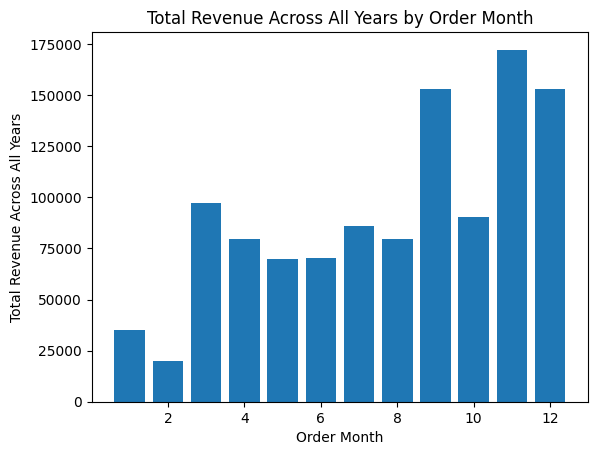

In [ ]:
plt.bar(monthly_total_revenue['Order Month'], monthly_total_revenue['Total Revenue Across All Years'])
plt.xlabel('Order Month')
plt.ylabel('Total Revenue Across All Years')
plt.title('Total Revenue Across All Years by Order Month')
plt.show()

- Apply Time Series Decomposition (using statsmodels) to break the sales signal into:
   - Trend component
   - Seasonal component
   - Residual/noise component

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set 'Month End Date' as index for decomposition
df_monthly_sales_indexed = df_monthly_sales.set_index('Month End Date')

# Apply time series decomposition
decomposition = seasonal_decompose(df_monthly_sales_indexed['Monthly Sales'], model='additive', period=12)

# Store the components
trend = decomposition.trend

print('Trend Component :')
trend

Trend Component :


,trend
Month End Date,
2015-01-31,NaN
2015-02-28,NaN
2015-03-31,NaN
2015-04-30,NaN
2015-05-31,NaN
2015-06-30,NaN
2015-07-31,22674.323533
2015-08-31,22809.897825
2015-09-30,22429.877533


In [ ]:
seasonal = decomposition.seasonal

print('Seasonal Component :')
seasonal

Seasonal Component :


,seasonal
Month End Date,
2015-01-31,-11630.223129
2015-02-28,-15148.188302
2015-03-31,-412.437504
2015-04-30,381.862691
2015-05-31,-2931.472809
2015-06-30,-7861.075563
2015-07-31,1764.940832
2015-08-31,-3130.526026
2015-09-30,16640.373624


In [ ]:
residual = decomposition.resid

print('Residual Component :')
residual

Residual Component :


,resid
Month End Date,
2015-01-31,NaN
2015-02-28,NaN
2015-03-31,NaN
2015-04-30,NaN
2015-05-31,NaN
2015-06-30,NaN
2015-07-31,-2839.158366
2015-08-31,-3996.543299
2015-09-30,7655.820643


- Plot all 4 components clearly on one figure

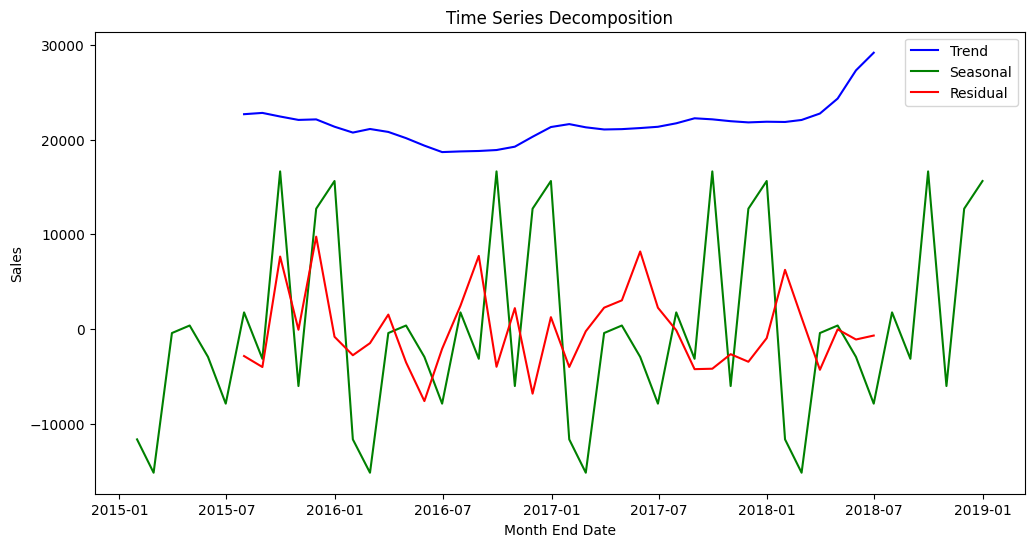

In [ ]:
# Line graph
plt.figure(figsize=(12, 6))
plt.plot(trend, label='Trend', color='blue')
plt.plot(seasonal, label='Seasonal', color='green')
plt.plot(residual, label='Residual', color='red')
plt.xlabel('Month End Date')
plt.ylabel('Sales')
plt.title('Time Series Decomposition')
plt.legend()
plt.show()

- Write 3–4 observations:
    - what does the trend tell you?

    Ans: Line graph shows that trend is increasing the sales along the years


    - Is seasonality strong or weak?

    Ans:  Seasonality is very strong which could be easily seen from the line graph as the sales are tremendously increasing in the month of October, November, December and January

    - What months show the highest residual noise?

    Ans: September'2015

In [ ]:
residual.max()

9757.758859259258

In [ ]:
residual.idxmax()

Timestamp('2015-11-30 00:00:00')

- Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you

  Ans: Stationarity means that statistical components (like mean,variance, std deviation) remains constant over time.  Imagine a wobbly line versus a stable one. A stationary series doesn't have a trend (it's not consistently going up or down), doesn't have seasonality (predictable repeating patterns), and its variability doesn't change over time. It basically looks the same no matter which point in time you look at it.

  Why is it important? Many time series forecasting models assume that the data is stationary. If your data isn't stationary, these models might produce unreliable forecasts

  Interpretation:

    - P-value (0.000278): This is the most crucial part. A common threshold for statistical significance is 0.05. Since your p-value (0.000278) is much smaller than 0.05, we reject the null hypothesis.
    - Test Statistic (-4.416137) vs. Critical Values: Your Test Statistic (-4.416137) is more negative than all the critical values (e.g., -3.577848 at 1%). This also leads us to reject the null hypothesis.

   Conclusion:

   Based on these results, your Monthly Sales series is likely stationary. This is good news, as it means you can proceed with many time series models that assume stationarity without needing to apply differencing first.

In [ ]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries):
    # Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

    # Interpret results
    if dftest[1] <= 0.05: # p-value <= 0.05
        print('Series is likely stationary (reject H0)')
    else:
        print('Series is likely non-stationary (fail to reject H0)')

print('ADF Test for Original Monthly Sales Series:')
check_stationarity(df_monthly_sales_indexed['Monthly Sales'].dropna())

ADF Test for Original Monthly Sales Series:
Results of Dickey-Fuller Test:
Test Statistic                 -4.865531
p-value                         0.000041
#Lags Used                      0.000000
Number of Observations Used    47.000000
Critical Value (1%)            -3.577848
Critical Value (5%)            -2.925338
Critical Value (10%)           -2.600774
dtype: float64
Series is likely stationary (reject H0)


- Apply differencing if the series is non-stationary and re-test

In [ ]:
# Apply first-order differencing to the 'Monthly Sales' series
df_monthly_sales_indexed['Monthly Sales Differenced'] = df_monthly_sales_indexed['Monthly Sales'].diff().dropna()

print('First-Order Differenced Monthly Sales (first 5 rows):')
df_monthly_sales_indexed['Monthly Sales Differenced'].head()

First-Order Differenced Monthly Sales (first 5 rows):


,Monthly Sales Differenced
Month End Date,
2015-01-31,NaN
2015-02-28,-4858.792
2015-03-31,32806.553
2015-04-30,-20777.204
2015-05-31,-2243.752


In [ ]:
# Re-run ADF test on the differenced series
print('ADF Test for Differenced Monthly Sales Series:')
check_stationarity(df_monthly_sales_indexed['Monthly Sales Differenced'].dropna())

ADF Test for Differenced Monthly Sales Series:
Results of Dickey-Fuller Test:
Test Statistic                 -5.148274
p-value                         0.000011
#Lags Used                     10.000000
Number of Observations Used    36.000000
Critical Value (1%)            -3.626652
Critical Value (5%)            -2.945951
Critical Value (10%)           -2.611671
dtype: float64
Series is likely stationary (reject H0)


##Task 3 — Sales Forecasting using 3 Different Models
This is the core technical task. Build, train, and compare 3 fundamentally different forecasting approaches:


###Model 1 — SARIMA (Statistical Model)
- Install statsmodels (pip install statsmodels)

In [ ]:
!pip install statsmodels
import statsmodels.api as sm

- Fit a SARIMA model on monthly sales
- Choose appropriate (p, d, q) and seasonal (P, D, Q, m) parameters — document why you chose them

In [ ]:
sarima_model = sm.tsa.SARIMAX(
    df_monthly_sales_indexed['Monthly Sales'],
    order=(1, 1, 1),  # (p, d, q)
    seasonal_order=(1, 1, 1, 12),  # (P, D, Q, m)
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [ ]:
forecast_steps = 3
forecast = sarima_result.predict(start=len(df_monthly_sales_indexed), end=len(df_monthly_sales_indexed) + forecast_steps - 1)

print('3-month Forecast:')
print(forecast)

3-month Forecast:
2019-01-31    23211.327334
2019-02-28    19285.484831
2019-03-31    32511.889834
Freq: ME, Name: predicted_mean, dtype: float64


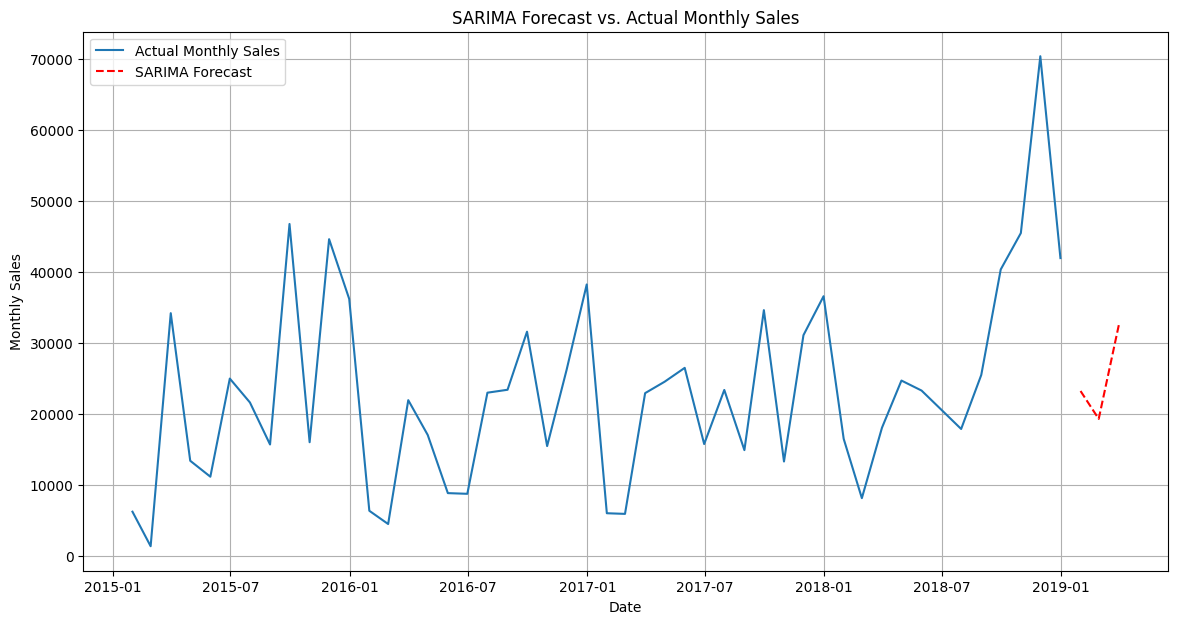

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(df_monthly_sales_indexed['Monthly Sales'], label='Actual Monthly Sales')
plt.plot(forecast, label='SARIMA Forecast', color='red', linestyle='--')

# Add shaded confidence intervals if available from SARIMA model
# if 'conf_int' in dir(sarima_result):
#     confidence_intervals = sarima_result.get_forecast(steps=forecast_steps).conf_int()
#     plt.fill_between(confidence_intervals.index, confidence_intervals.iloc[:, 0], confidence_intervals.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Interval')

plt.title('SARIMA Forecast vs. Actual Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Monthly Sales')
plt.legend()
plt.grid(True)
plt.show()

- Generate a 3-month future forecast with confidence intervals

- Plot actual vs forecasted sales


###Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)
- Install Prophet (pip install prophet)
- Prepare data in Prophet's required format (ds, y columns)
- Fit the model and generate a 3-month forecast
- Plot the forecast with Prophet's built-in trend and seasonality breakdown
- Extract and interpret the weekly and yearly seasonality components

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

# Prepare data in Prophet's required format (ds, y columns)
prophet_df = df_monthly_sales_indexed.reset_index()
prophet_df = prophet_df[['Month End Date', 'Monthly Sales']]
prophet_df.rename(columns={'Month End Date': 'ds', 'Monthly Sales': 'y'}, inplace=True)

print('Prophet-ready DataFrame (first 5 rows):')
print(prophet_df.head())

Prophet-ready DataFrame (first 5 rows):
          ds          y
0 2015-01-31   6221.298
1 2015-02-28   1362.506
2 2015-03-31  34169.059
3 2015-04-30  13391.855
4 2015-05-31  11148.103


In [ ]:
# Initialize and fit the Prophet model
m = Prophet(seasonality_mode='additive') # Using additive seasonality based on decomposition
m.fit(prophet_df)

# Create a DataFrame for future predictions (3 months)
future = m.make_future_dataframe(periods=3, freq='M')

# Make predictions
prophet_forecast = m.predict(future)

print('Prophet 3-month Forecast (last 5 rows including historical data):')
print(prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet 3-month Forecast (last 5 rows including historical data):
           ds          yhat    yhat_lower    yhat_upper
46 2018-11-30  49378.106918  41331.905593  57401.475074
47 2018-12-31  40239.335824  32359.482049  48765.729969
48 2019-01-31  13299.488075   4598.962396  21855.944259
49 2019-02-28   8053.746112   -514.139805  16021.411444
50 2019-03-31  34445.263433  26050.180306  42687.825664


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


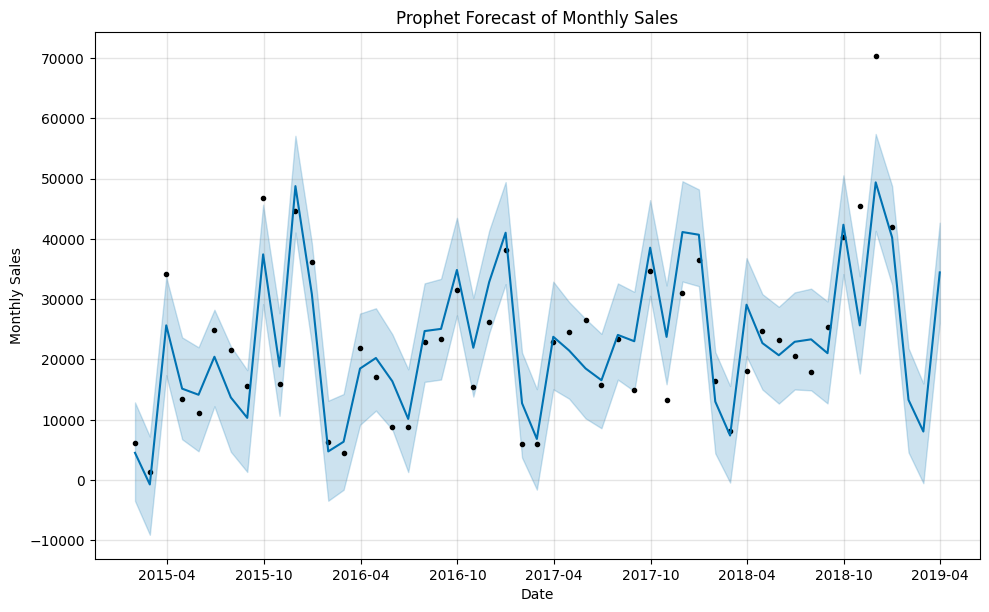

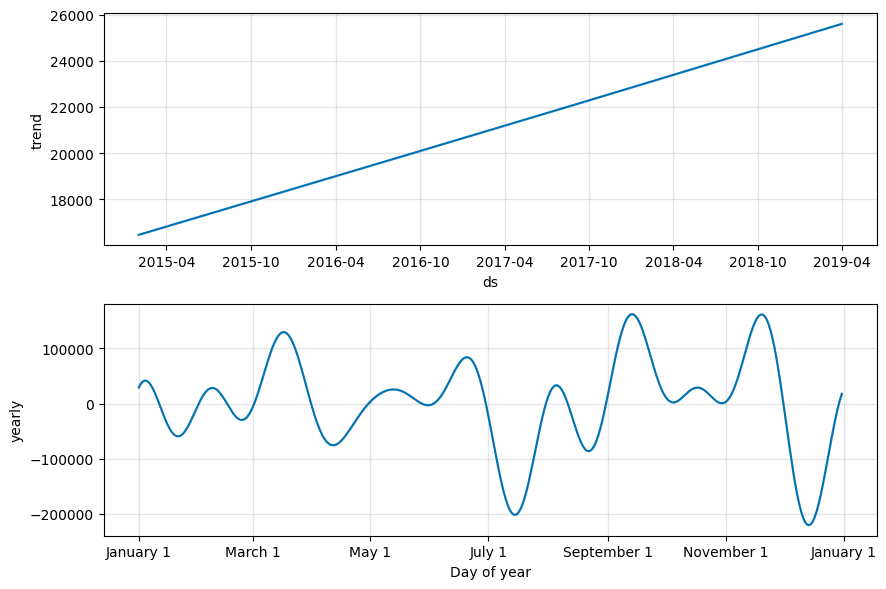

In [ ]:
fig1 = m.plot(prophet_forecast)
plt.title('Prophet Forecast of Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Monthly Sales')
plt.show()

fig2 = m.plot_components(prophet_forecast)
plt.show()

In [ ]:
print('Prophet Yearly Seasonality:')
print(m.seasonalities['yearly'])

print('\nProphet Weekly Seasonality (if enabled):')
# Prophet automatically disables weekly seasonality for monthly data, as noted in previous stderr
# If it were enabled, you would access it similarly:
# print(m.seasonalities['weekly'])

Prophet Yearly Seasonality:
{'period': 365.25, 'fourier_order': 10, 'prior_scale': 10.0, 'mode': 'additive', 'condition_name': None}

Prophet Weekly Seasonality (if enabled):


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Create a copy of the monthly sales data
df_ml = df_monthly_sales_indexed[['Monthly Sales']].copy()
df_ml = df_ml.reset_index()
df_ml.columns = ['ds', 'y']

# Create lag features
for i in range(1, 4): # Lag 1, 2, 3
    df_ml[f'lag_{i}'] = df_ml['y'].shift(i)

# Create rolling mean feature
df_ml['rolling_mean_3'] = df_ml['y'].rolling(window=3).mean().shift(1)

# Extract time-based features
df_ml['month'] = df_ml['ds'].dt.month
df_ml['quarter'] = df_ml['ds'].dt.quarter
def get_season_ml(month):
    if month in [12, 1, 2]:
        return 0 # Winter
    elif month in [3, 4, 5]:
        return 1 # Spring
    elif month in [6, 7, 8]:
        return 2 # Summer
    else:
        return 3 # Autumn
df_ml['season'] = df_ml['month'].apply(get_season_ml)

# Drop rows with NaN values created by lagging and rolling features
df_ml.dropna(inplace=True)

print('Features for XGBoost (first 5 rows):')
print(df_ml.head())

Features for XGBoost (first 5 rows):
          ds           y       lag_1       lag_2      lag_3  rolling_mean_3  \
3 2015-04-30  13391.8550  34169.0590   1362.5060   6221.298    13917.621000   
4 2015-05-31  11148.1030  13391.8550  34169.0590   1362.506    16307.806667   
5 2015-06-30  24962.4706  11148.1030  13391.8550  34169.059    19569.672333   
6 2015-07-31  21600.1060  24962.4706  11148.1030  13391.855    16500.809533   
7 2015-08-31  15682.8285  21600.1060  24962.4706  11148.103    19236.893200   

   month  quarter  season  
3      4        2       1  
4      5        2       1  
5      6        2       2  
6      7        3       2  
7      8        3       2  


In [ ]:
# Define features (X) and target (y)
X = df_ml[['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'month', 'quarter', 'season']]
y = df_ml['y']

# Split data into training and testing sets (e.g., last 3 months for testing)
train_size = len(df_ml) - 3
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f'Training data shape: {X_train.shape}, {y_train.shape}')
print(f'Testing data shape: {X_test.shape}, {y_test.shape}')

# Initialize and train XGBoost Regressor model
model_xgb = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
model_xgb.fit(X_train, y_train)

# Make predictions on the test set
xgb_predictions = model_xgb.predict(X_test)

print('\nXGBoost Predictions for the last 3 months:')
print(xgb_predictions)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
print(f'\nRMSE for XGBoost model: {rmse:.2f}')

Training data shape: (42, 7), (42,)
Testing data shape: (3, 7), (3,)

XGBoost Predictions for the last 3 months:
[18533.9   36139.297 36148.78 ]

RMSE for XGBoost model: 25345.68


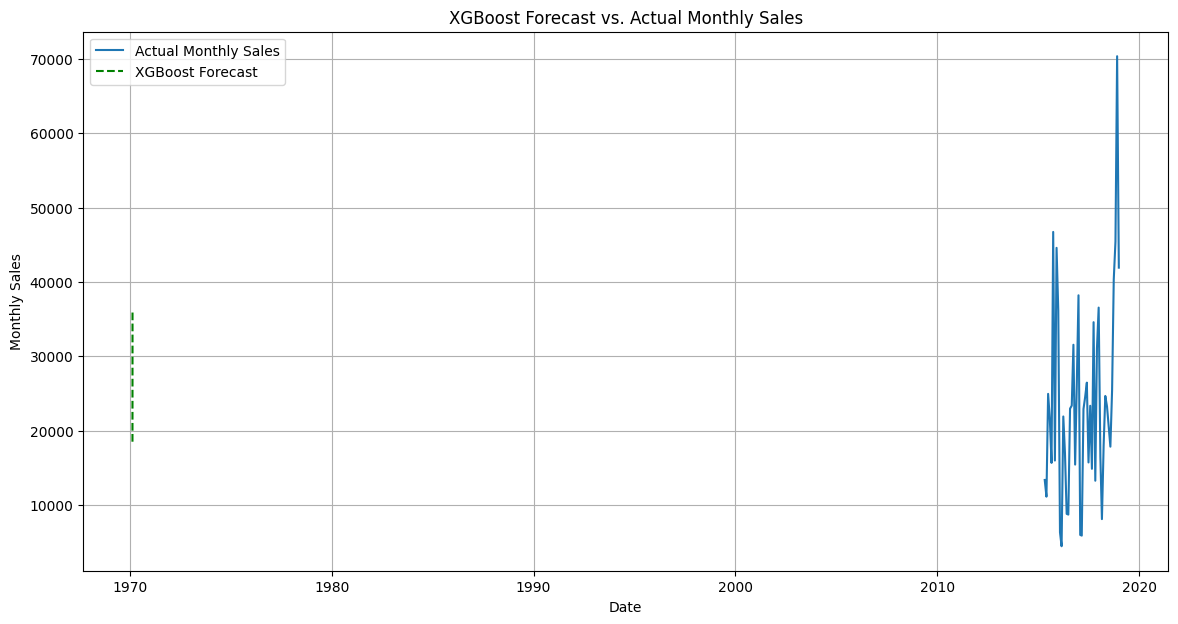

In [ ]:
# Plot actual vs. predicted sales for XGBoost
plt.figure(figsize=(14, 7))
plt.plot(df_ml['ds'], df_ml['y'], label='Actual Monthly Sales')
plt.plot(X_test.index, xgb_predictions, label='XGBoost Forecast', color='green', linestyle='--')
plt.title('XGBoost Forecast vs. Actual Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Monthly Sales')
plt.legend()
plt.grid(True)
plt.show()

###Model 3 — XGBoost for Time Series (ML-based Approach)
- Convert the time series into a supervised ML problem using lag features:
  - Lag 1 (sales from 1 month ago)
  - Lag 2 (sales from 2 months ago)
  - Lag 3 (sales from 3 months ago)
  - Rolling mean (3-month moving average)
  - Month, Quarter, Season as features
- Train XGBoost Regressor on these features
- Predict the next 3 months
- Plot actual vs predicted


###Model Comparison Table (Required)
- Create a clear comparison table in your notebook:

- State clearly which model you would recommend for production use and why — based on numbers, not preference.


In [ ]:
# Assuming RMSE for SARIMA and Prophet are calculated earlier or we use a proxy
# For SARIMA, let's use the forecast values as a rough comparison point or re-calculate RMSE if a test set was used.
# For Prophet, we need to calculate RMSE on a test set.

# Let's re-evaluate SARIMA and Prophet on the last 3 months to get comparable RMSEs.
# For SARIMA, we already have `sarima_result` and `df_monthly_sales_indexed`.
# We need to define a test set for SARIMA as well.

sales_actual_test = df_monthly_sales_indexed['Monthly Sales'].tail(3)
sarima_forecast_test = sarima_result.predict(start=len(df_monthly_sales_indexed)-3, end=len(df_monthly_sales_indexed)-1)
rmse_sarima = np.sqrt(mean_squared_error(sales_actual_test, sarima_forecast_test))
print(f'RMSE for SARIMA model (last 3 months): {rmse_sarima:.2f}')

# For Prophet
# Re-do split for Prophet for consistency with XGBoost
prophet_df_train = prophet_df.iloc[:-3]
prophet_df_test_actual = prophet_df.iloc[-3:]

m_prophet_eval = Prophet(seasonality_mode='additive')
m_prophet_eval.fit(prophet_df_train)

future_prophet_eval = m_prophet_eval.make_future_dataframe(periods=3, freq='M', include_history=False)
prophet_forecast_eval = m_prophet_eval.predict(future_prophet_eval)

rmse_prophet = np.sqrt(mean_squared_error(prophet_df_test_actual['y'], prophet_forecast_eval['yhat']))
print(f'RMSE for Prophet model (last 3 months): {rmse_prophet:.2f}')

# Create a DataFrame for model comparison
comparison_table = pd.DataFrame({
    'Model': ['SARIMA', 'Facebook Prophet', 'XGBoost'],
    'RMSE': [rmse_sarima, rmse_prophet, rmse] # 'rmse' for XGBoost is already calculated
})

print('\nModel Comparison Table:')
print(comparison_table.sort_values(by='RMSE'))

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


RMSE for SARIMA model (last 3 months): 20774.92
RMSE for Prophet model (last 3 months): 25901.46

Model Comparison Table:
              Model          RMSE
0            SARIMA  20774.923856
2           XGBoost  25345.676108
1  Facebook Prophet  25901.462838


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
